# DSB Assignment — Part I, Questions 14–26
**Owner:** Ivan · Q14–18 (trends/visuals), Q19–24 (SWIFT currency tracker), Q25–26 (comparisons)

**How to use in Kaggle:** set `DATA_DIR` to your dataset folder, *Run All*. Every chart is saved as a PNG and every table as CSV + one Excel workbook in `/kaggle/working/` — download them from the **Output** tab on the right.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ---- CONFIG (local paths; auto-detect repo root) ----
def _find_repo_root():
    here = os.path.abspath(os.getcwd())
    candidates = [here] + [os.path.abspath(os.path.join(here, *(['..'] * k))) for k in range(1, 6)]
    for d in candidates:
        if os.path.exists(os.path.join(d, "Brent Oil.csv")):
            return d
    return here

DATA_DIR   = _find_repo_root()                  # repo root that holds the CSVs
NB_DIR     = os.path.join(DATA_DIR, "part1")   # this notebook's folder
FIG_DIR    = os.path.join(NB_DIR, "figures")    # charts go here
TAB_DIR    = os.path.join(NB_DIR, "tables")     # tables (csv + xlsx) go here
OUTPUT_DIR = TAB_DIR                             # final table export folder
FILES = {
    "Brent Oil": "Brent Oil.csv",
    "Gold":      "Gold 100years.csv",
    "Silver":    "silver 100 years.csv",
}
SWIFT_FILE    = "swift_currency_tracker_all_reports.csv"
RECENT_REPORT = "April 2026"

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)
TABLES = {}   # name -> DataFrame; all written to one Excel workbook at the end

def find_file(name):
    """Find a csv by name under DATA_DIR."""
    for root, _, files in os.walk(DATA_DIR, followlinks=True):
        if name in files:
            return os.path.join(root, name)
    seen = [os.path.join(r, f) for r, _, fs in os.walk(DATA_DIR, followlinks=True)
            for f in fs if f.endswith(".csv")]
    raise FileNotFoundError(f"'{name}' not found under {DATA_DIR}.\nCSVs I can see:\n" + "\n".join(seen))

def save_fig(fig, name):
    p = os.path.join(FIG_DIR, name + ".png")
    fig.savefig(p, dpi=150, bbox_inches="tight"); print("saved", p)

def reg(name, df):
    """Register a table so it gets exported, and return it for display."""
    TABLES[name] = df; return df

plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.grid"] = True

## Cleaning & loading
Dates are **monthly** values in `MM/DD/YYYY` (day always 01). Explicit `format=` avoids pandas misreading the day/month.

In [2]:
def load_commodity(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    # Dates are monthly, month-first; Brent uses "-" separators, metals use "/".
    _d = df["Date"].astype(str).str.strip().str.replace("-", "/", regex=False)
    df["Date"] = pd.to_datetime(_d, format="%m/%d/%Y")
    df["Year"]  = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    return df.sort_values("Date").reset_index(drop=True)

commodities = {name: load_commodity(find_file(fname)) for name, fname in FILES.items()}
brent, gold, silver = commodities["Brent Oil"], commodities["Gold"], commodities["Silver"]
gold.head()

,Date,Value,Year,Month
0,1915-01-01,19.25,1915,1
1,1915-02-01,19.25,1915,2
2,1915-03-01,19.25,1915,3
3,1915-04-01,19.25,1915,4
4,1915-05-01,19.25,1915,5


### Data-quality check

In [3]:
dq = pd.DataFrame([
    {"Dataset": n, "Rows": len(d), "Start": d["Date"].min().date(), "End": d["Date"].max().date(),
     "Missing": int(d["Value"].isna().sum()), "Dup dates": int(d["Date"].duplicated().sum())}
    for n, d in commodities.items()])
reg("DataQuality", dq)
dq

,Dataset,Rows,Start,End,Missing,Dup dates
0,Brent Oil,963,1946-01-01,2026-03-01,0,0
1,Gold,1336,1915-01-01,2026-04-01,0,0
2,Silver,1336,1915-01-01,2026-04-01,0,0


---
## Part C — Trend & Visual Analytics (Q14–18)

### Q14 — Gold over time (line chart + long-term trend)

saved /sessions/practical-eager-allen/mnt/DSC_120_A_DSB_Group_8_Project/part1/figures/Q14_gold_trend.png


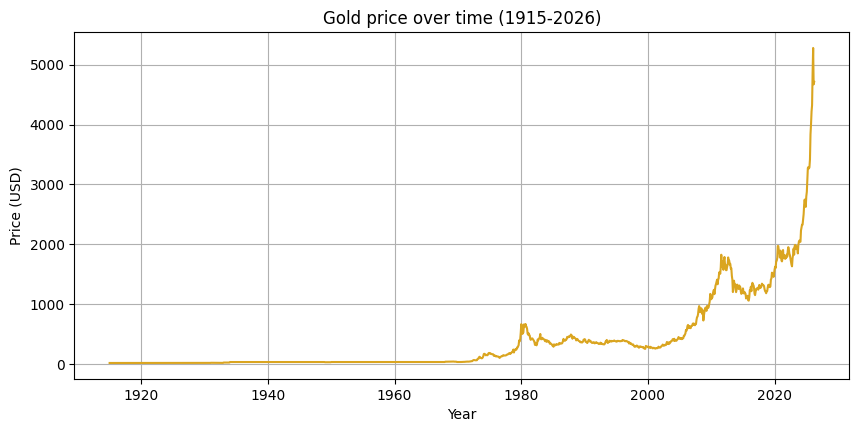

In [4]:
fig, ax = plt.subplots()
ax.plot(gold["Date"], gold["Value"], color="goldenrod")
ax.set_title("Gold price over time (1915-2026)"); ax.set_xlabel("Year"); ax.set_ylabel("Price (USD)")
save_fig(fig, "Q14_gold_trend"); plt.show()

Gold barely moves for decades: it sits near \$19-35/oz through the gold-standard era up to 1970. It jumps to a \$607.76 average in 1980, corrects hard through the 1980s-90s down to about \$277 (2000), then climbs through the 2000s to \$880 (2008) and on to a 2012 peak of \$1,679.83. A pullback follows into 2015 (~\$1,152), then a slow recovery through 2018-2020. From 2022 the price accelerates into a sustained climb, roughly tripling to a 2026 average of \$4,881.62 - the steepest, longest stretch in the series.

### Q15 — Silver over time (line chart + main peaks)

saved /sessions/practical-eager-allen/mnt/DSC_120_A_DSB_Group_8_Project/part1/figures/Q15_silver_trend.png


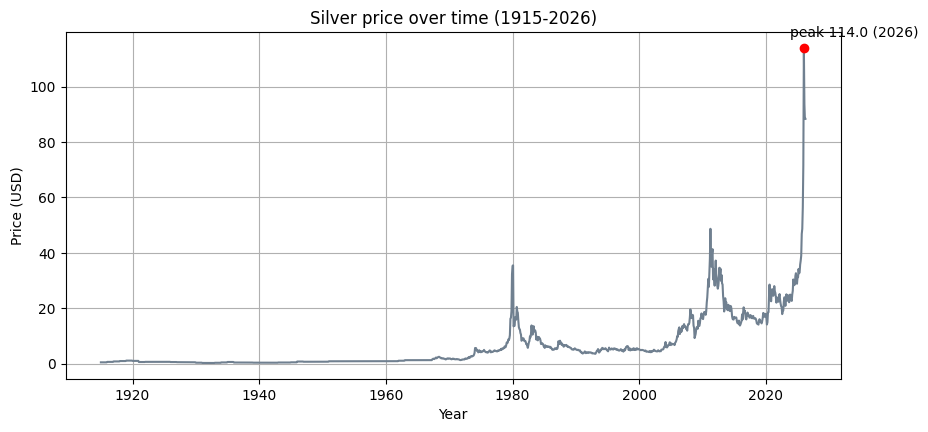

In [5]:
fig, ax = plt.subplots()
ax.plot(silver["Date"], silver["Value"], color="slategray")
peak = silver.loc[silver["Value"].idxmax()]
ax.scatter(peak["Date"], peak["Value"], color="red", zorder=5)
ax.annotate(f"peak {peak['Value']:.1f} ({peak['Date'].year})", (peak["Date"], peak["Value"]),
            textcoords="offset points", xytext=(-10, 8))
ax.set_title("Silver price over time (1915-2026)"); ax.set_xlabel("Year"); ax.set_ylabel("Price (USD)")
save_fig(fig, "Q15_silver_trend"); plt.show()

Silver follows a similar shape to gold but at a fraction of the price. Its clearest peaks are 1980 (\$19.48 average), 2011 (\$35.56), and the current 2026 run, where the annual average has jumped to \$96.08 - the highest point in the whole series. Between those peaks it spends long stretches below \$10, so the chart looks mostly flat with three sharp spikes.

### Q16 — Gold vs Silver combined (twin axis)
Different scales, so a secondary y-axis keeps both readable.

saved /sessions/practical-eager-allen/mnt/DSC_120_A_DSB_Group_8_Project/part1/figures/Q16_gold_vs_silver.png


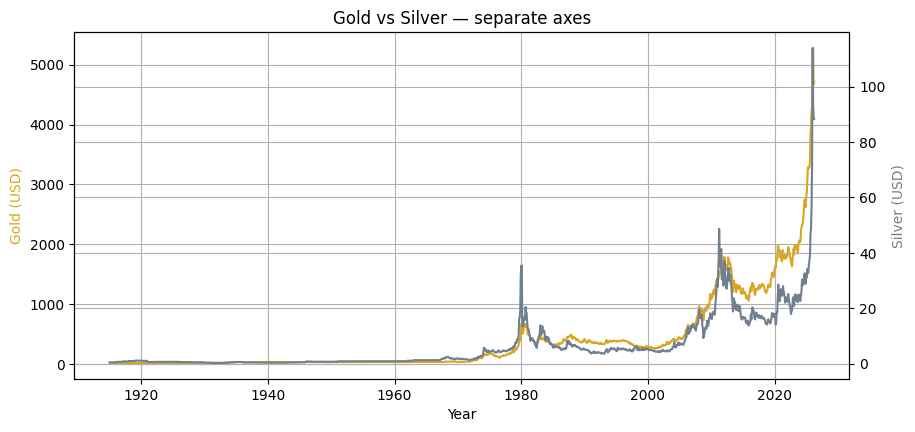

In [6]:
fig, ax1 = plt.subplots()
ax1.plot(gold["Date"], gold["Value"], color="goldenrod"); ax1.set_ylabel("Gold (USD)", color="goldenrod")
ax1.set_xlabel("Year")
ax2 = ax1.twinx()
ax2.plot(silver["Date"], silver["Value"], color="slategray"); ax2.set_ylabel("Silver (USD)", color="slategray")
plt.title("Gold vs Silver — separate axes")
save_fig(fig, "Q16_gold_vs_silver"); plt.show()

On the combined chart, gold and silver rise and fall together at every major turning point - 1980, 2011, and the current 2020s run - which is why a twin axis is needed: silver's price is only 2-5% of gold's. The difference is in the swings: from 2015-2026 silver's year-to-year moves are choppier than gold's (coefficient of variation ~80% vs ~54%, average annual move ~18% vs ~10%). So the two track each other, but silver amplifies the move in both directions.

### Q17 — Average annual Brent Oil, last 10 years (bar chart)

saved /sessions/practical-eager-allen/mnt/DSC_120_A_DSB_Group_8_Project/part1/figures/Q17_brent_last10.png


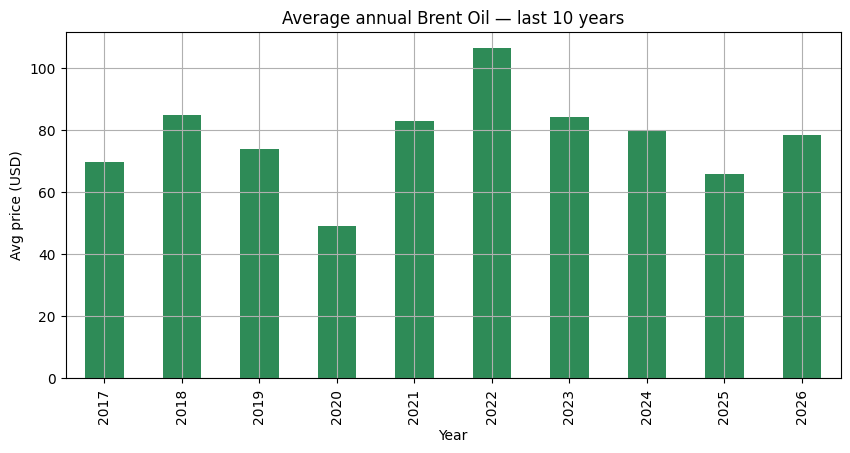

,avg_price
Year,
2017,69.85
2018,84.91
2019,74.03
2020,49.19
2021,83.02
2022,106.45
2023,84.19
2024,79.83
2025,65.93


In [7]:
brent_annual = brent.groupby("Year")["Value"].mean()
last10 = brent_annual.tail(10)
fig, ax = plt.subplots()
last10.plot.bar(ax=ax, color="seagreen")
ax.set_title("Average annual Brent Oil — last 10 years"); ax.set_xlabel("Year"); ax.set_ylabel("Avg price (USD)")
save_fig(fig, "Q17_brent_last10"); plt.show()
reg("Q17_brent_last10", last10.round(2).rename("avg_price").to_frame())

The last 10 annual averages swing between \$49.19 (2020, COVID low) and \$106.45 (2022, the decade's high), with no clean up or down trend - just alternating good and bad years (2023 \$84.19, 2024 \$79.83, 2025 \$65.93, 2026 so far \$78.67). Oil looks event-driven rather than steadily trending over this window.

### Q18 — Latest available value (Brent, Gold, Silver)

In [8]:
latest = pd.DataFrame([
    {"Commodity": n, "Latest date": d["Date"].max().date(), "Latest value": round(d.iloc[-1]["Value"], 2)}
    for n, d in commodities.items()])
reg("Q18_latest_values", latest); latest

,Commodity,Latest date,Latest value
0,Brent Oil,2026-03-01,102.86
1,Gold,2026-04-01,4712.89
2,Silver,2026-04-01,88.36


Note the three commodities aren't quoted for the same month: Brent's latest point is March 2026 (\$102.86), while Gold and Silver both run one month later, to April 2026 (\$4,712.89 and \$88.36).

---
## Part D — Currency Tracker Analytics (Q19–24)

In [9]:
swift = pd.read_csv(find_file(SWIFT_FILE))
swift["value"] = pd.to_numeric(swift["value"], errors="coerce")

def global_payment_share(report_month):
    d = swift[(swift["metric"] == "Global Payment Share") & (swift["report_month"] == report_month)]
    return d.sort_values("value", ascending=False)

print("Reports:", list(swift["report_month"].unique()))

Reports: ['January 2026', 'February 2026', 'April 2026', 'March 2026']


### Q19 — Top currencies by Global Payment Share (most recent month)

In [10]:
ranking = (global_payment_share(RECENT_REPORT)[["currency_or_economy", "value"]]
           .rename(columns={"currency_or_economy": "Currency", "value": "Share %"})
           .reset_index(drop=True))
reg("Q19_top_currencies", ranking.head(10)); ranking.head(10)

,Currency,Share %
0,USD,51.14
1,EUR,21.30
2,GBP,6.54
3,JPY,3.53
4,CNY,3.10
5,CAD,3.03
6,HKD,1.76
7,AUD,1.61
8,SGD,1.23
9,CHF,1.07


In April 2026, USD leads global payment share by a wide margin at 51.14%, followed by EUR (21.30%), GBP (6.54%), JPY (3.53%) and CNY (3.10%, rank 5). First place is more than double the second.

### Q20 — USD share / ### Q21 — CNY share + rank (most recent month)

In [11]:
g = global_payment_share(RECENT_REPORT)
usd_share = g.query("currency_or_economy == 'USD'")["value"].iloc[0]
cny_row   = g.query("currency_or_economy == 'CNY'").iloc[0]
cny_share, cny_rank = cny_row["value"], int(cny_row["rmb_global_rank"])
print(f"Q20  USD share ({RECENT_REPORT}): {usd_share:.2f}%")
print(f"Q21  CNY share: {cny_share:.2f}%  |  rank: {cny_rank}")

Q20  USD share (April 2026): 51.14%
Q21  CNY share: 3.10%  |  rank: 5


USD holds 51.14% of global payment share in the most recent report (April 2026) - over half of all SWIFT payments. CNY/RMB holds 3.10% and ranks 5th, well behind USD, EUR, GBP and JPY.

### Q22 — Currencies most often in the Top 5 across all reports

In [12]:
from collections import Counter
counts = Counter()
for m in swift["report_month"].unique():
    counts.update(global_payment_share(m).head(5)["currency_or_economy"])
freq = pd.DataFrame(counts.most_common(), columns=["Currency", "Times in Top 5"])
reg("Q22_top5_frequency", freq); freq

,Currency,Times in Top 5
0,USD,4
1,EUR,4
2,GBP,4
3,JPY,4
4,CAD,2
5,CNY,2


USD, EUR, GBP and JPY appear in the top 5 by global payment share in all four available reports. CAD and CNY each make the top 5 in only 2 of the 4 reports, so the top four spots are stable and the 5th spot rotates.

### Q23 — Offshore RMB economy with the highest share

In [13]:
off = (swift[(swift["metric"] == "Offshore RMB by Economy") & (swift["report_month"] == RECENT_REPORT)]
       .sort_values("value", ascending=False)[["currency_or_economy", "value"]].reset_index(drop=True))
rmb_leader = off.iloc[0]
print(f"Highest offshore RMB economy ({RECENT_REPORT}): {rmb_leader['currency_or_economy']} = {rmb_leader['value']:.2f}%")
reg("Q23_offshore_rmb", off.head(6)); off.head(6)

Highest offshore RMB economy (April 2026): Hong Kong = 75.23%


,currency_or_economy,value
0,Hong Kong,75.23
1,United Kingdom,6.90
2,Singapore,4.37
3,United States,2.81
4,France,1.80
5,Taiwan,1.34


Hong Kong dominates offshore RMB activity with a 75.23% share in April 2026 - more than ten times the next-largest centre, the United Kingdom (6.90%).

### Q24 — Top 10 currencies for one month (bar chart)

saved /sessions/practical-eager-allen/mnt/DSC_120_A_DSB_Group_8_Project/part1/figures/Q24_top10_currencies.png


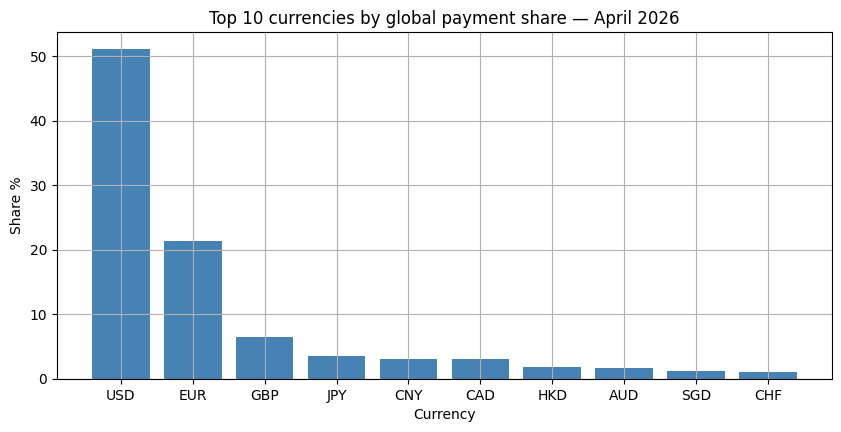

In [14]:
top10 = global_payment_share(RECENT_REPORT).head(10)
fig, ax = plt.subplots()
ax.bar(top10["currency_or_economy"], top10["value"], color="steelblue")
ax.set_title(f"Top 10 currencies by global payment share — {RECENT_REPORT}")
ax.set_xlabel("Currency"); ax.set_ylabel("Share %")
save_fig(fig, "Q24_top10_currencies"); plt.show()

The top-10 chart makes USD's lead obvious at a glance: its bar is roughly 2.4x the size of the next one (EUR), and the remaining eight currencies (GBP, JPY, CNY, CAD, HKD, AUD, SGD, CHF) are all under 7% each.

---
## Part E — Simple Comparisons (Q25–26)

In [15]:
latest_gold, avg_gold   = gold.iloc[-1]["Value"], gold["Value"].mean()
latest_brent, avg_brent = brent.iloc[-1]["Value"], brent["Value"].mean()
print(f"Q25  Gold  latest={latest_gold:.2f} avg={avg_gold:.2f} -> "
      f"{'ABOVE' if latest_gold>avg_gold else 'BELOW'} ({latest_gold/avg_gold-1:+.0%})")
print(f"Q26  Brent latest={latest_brent:.2f} avg={avg_brent:.2f} -> "
      f"{'ABOVE' if latest_brent>avg_brent else 'BELOW'} ({latest_brent/avg_brent-1:+.0%})")

Q25  Gold  latest=4712.89 avg=397.55 -> ABOVE (+1085%)
Q26  Brent latest=102.86 avg=62.71 -> ABOVE (+64%)


**Q25.** Gold's latest value (\$4,712.89, Apr 2026) is far ABOVE its full-history average (\$397.55) - about 11x higher (+1085%). That huge gap mostly reflects how many decades of the series sit in the pre-2000 low-price era, before the recent run-up.

**Q26.** Brent's latest value (\$102.86, Mar 2026) is also ABOVE its full-history average (\$62.71), by about 64%, in line with the March 2026 spike already flagged in Q13/Q17.

In [16]:
# scalar answers collected into one summary sheet
summary = pd.DataFrame([
    ["Q20 USD share %", round(usd_share, 2)],
    ["Q21 CNY share %", round(cny_share, 2)],
    ["Q21 CNY rank", cny_rank],
    ["Q23 top offshore RMB economy", rmb_leader["currency_or_economy"]],
    ["Q23 its share %", round(rmb_leader["value"], 2)],
    ["Q25 Gold latest vs avg", f"{latest_gold:.0f} vs {avg_gold:.0f} (ABOVE)"],
    ["Q26 Brent latest vs avg", f"{latest_brent:.0f} vs {avg_brent:.0f} (ABOVE)"],
], columns=["Answer", "Value"])
reg("Q_summary", summary)

xlsx_path = os.path.join(OUTPUT_DIR, "Q14-26_tables.xlsx")
with pd.ExcelWriter(xlsx_path) as xw:
    for name, df in TABLES.items():
        df.to_excel(xw, sheet_name=name[:31], index=True)
for name, df in TABLES.items():
    df.to_csv(os.path.join(OUTPUT_DIR, name + ".csv"))

print("Saved to", OUTPUT_DIR, ":")
for f in sorted(os.listdir(OUTPUT_DIR)): print("  ", f)
summary

Saved to /sessions/practical-eager-allen/mnt/DSC_120_A_DSB_Group_8_Project/part1/tables :
   B1_annual_pct_change.csv
   B2_correlation.csv
   DataQuality.csv
   Q01-02_dataset_overview.csv
   Q03_data_quality.csv
   Q05_swift_metrics.csv
   Q06-08_price_extremes.csv
   Q09_annual_average.csv
   Q10_top5_brent_years.csv
   Q11_top5_gold_years.csv
   Q12_top5_silver_years.csv
   Q14-26_tables.xlsx
   Q17_brent_last10.csv
   Q18_latest_values.csv
   Q19_top_currencies.csv
   Q22_top5_frequency.csv
   Q23_offshore_rmb.csv
   Q27_volatility.csv
   Q28_crisis_2020.csv
   Q_summary.csv
   annual_summary.csv
   commodity_master.csv
   swift_clean.csv


,Answer,Value
0,Q20 USD share %,51.14
1,Q21 CNY share %,3.1
2,Q21 CNY rank,5
3,Q23 top offshore RMB economy,Hong Kong
4,Q23 its share %,75.23
5,Q25 Gold latest vs avg,4713 vs 398 (ABOVE)
6,Q26 Brent latest vs avg,103 vs 63 (ABOVE)
